# Example-14: VEPP-4M models with dispersion

In [1]:
# Import

import numpy
import pandas
import torch
import yaml

import sys
sys.path.append('..')

from harmonica.util import mod
from harmonica.statistics import mean, variance
from harmonica.statistics import weighted_mean, weighted_variance
from harmonica.window import Window
from harmonica.data import Data
from harmonica.frequency import Frequency
from harmonica.filter import Filter
from harmonica.decomposition import Decomposition
from harmonica.model import Model
from harmonica.table import Table

import matplotlib.pyplot as plt

torch.set_printoptions(precision=12, sci_mode=True)
print(torch.cuda.is_available())

True


In [2]:
# Set data type and device

dtype = torch.float64
device = torch.device('cpu')

In [3]:
# Load inj and exp models

inj = Model(path='../vepp4m-inj.yaml')
exp = Model(path='../vepp4m-exp.yaml')

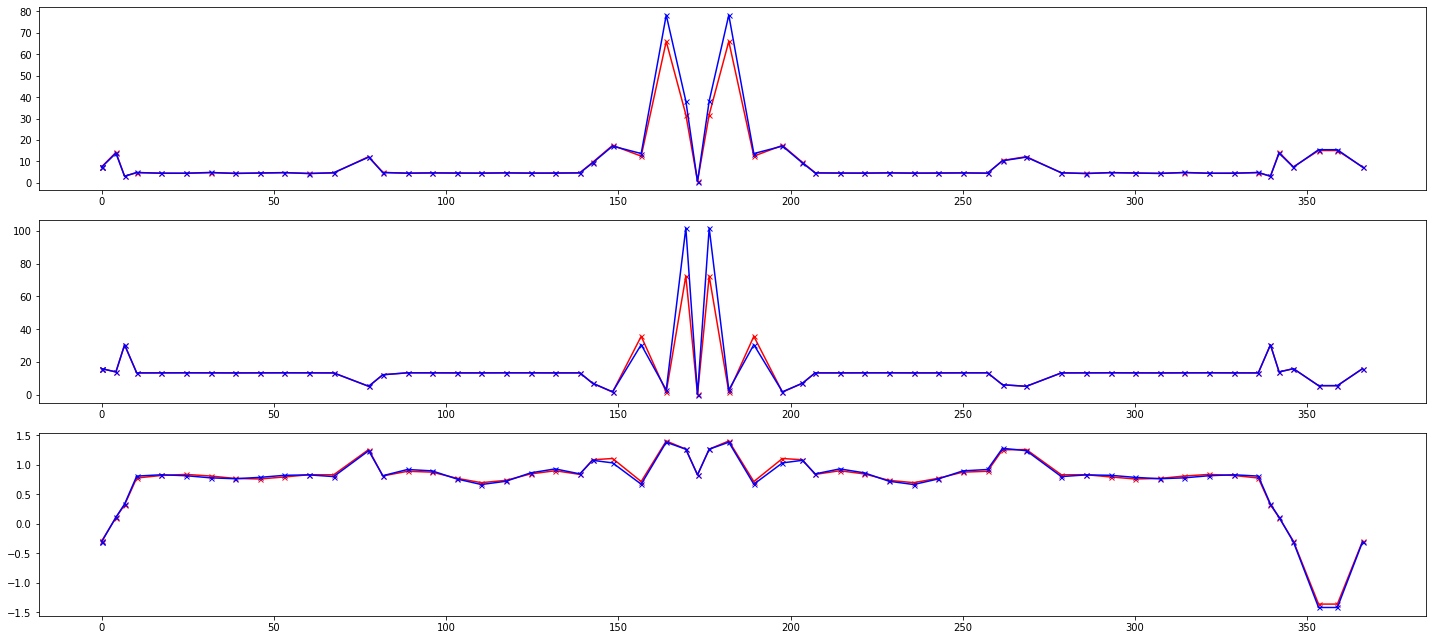

In [4]:
# Compare beta functions and dispersion
# Note, dispersion only accessible via data_frame instance

fig, (ax1, ax2, ax3) = plt.subplots(nrows=3, ncols=1, figsize=(20, 3*3))
ax1.errorbar(inj.time.cpu().numpy(), inj.bx.cpu().numpy(), marker='x', ms=5, color='red')
ax1.errorbar(exp.time.cpu().numpy(), exp.bx.cpu().numpy(), marker='x', ms=5, color='blue')
ax2.errorbar(inj.time.cpu().numpy(), inj.by.cpu().numpy(), marker='x', ms=5, color='red')
ax2.errorbar(exp.time.cpu().numpy(), exp.by.cpu().numpy(), marker='x', ms=5, color='blue')
ax3.errorbar(inj.time.cpu().numpy(), inj.data_frame.loc['DX'].values, marker='x', ms=5, color='red')
ax3.errorbar(exp.time.cpu().numpy(), exp.data_frame.loc['DX'].values, marker='x', ms=5, color='blue')
plt.tight_layout()
plt.show()